<a href="https://colab.research.google.com/github/PAJILAPIP/Muhammad-Fazil-Afif_2411531008_ML2526/blob/main/Praktikum3/TugasLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=16)

In [28]:
model_no_scaling = LogisticRegression(max_iter=3000)
model_no_scaling.fit(X_train, y_train)
y_pred_no_scale = model_no_scaling.predict(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LogisticRegression()
model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled)

print("Akurasi Tanpa Scaling:", accuracy_score(y_test, y_pred_no_scale))
print("Akurasi Dengan Scaling:", accuracy_score(y_test, y_pred_scaled))

Akurasi Tanpa Scaling: 0.935672514619883
Akurasi Dengan Scaling: 0.9649122807017544



--- Evaluasi Model (Threshold: 0.3) ---
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        65
           1       0.94      1.00      0.97       106

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



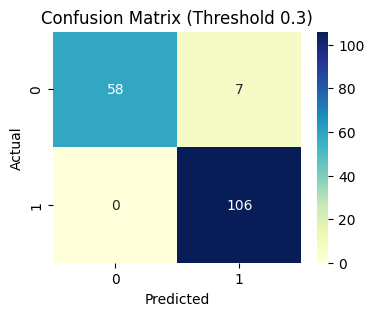


--- Evaluasi Model (Threshold: 0.5) ---
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        65
           1       0.96      0.98      0.97       106

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



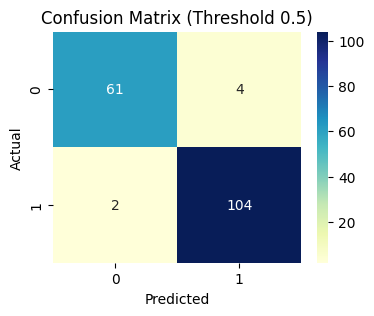


--- Evaluasi Model (Threshold: 0.7) ---
              precision    recall  f1-score   support

           0       0.94      0.95      0.95        65
           1       0.97      0.96      0.97       106

    accuracy                           0.96       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



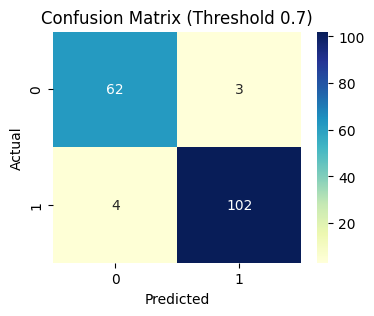

In [29]:
def evaluate_threshold(model, X_test, y_test, threshold):
    probs = model.predict_proba(X_test)[:, 1]

    custom_preds = (probs >= threshold).astype(int)

    print(f"\n--- Evaluasi Model (Threshold: {threshold}) ---")
    print(classification_report(y_test, custom_preds))

    cm = confusion_matrix(y_test, custom_preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='g', cmap="YlGnBu")
    plt.title(f'Confusion Matrix (Threshold {threshold})')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

thresholds = [0.3, 0.5, 0.7]
for t in thresholds:
    evaluate_threshold(model_scaled, X_test_scaled, y_test, t)